In [21]:
"""
Generate SDEC and LIV plots from a TARDIS configuration.

Provides a CLI and helpers to run a simulation and save SDEC and LIV plot
figures for a given configuration and atomic dataset.

Usage
-----
    python plot_from_config.py config.yml --output-prefix plot-name --output-dir ./outputs --format pdf
    python plot_from_config.py config.yml
    python plot_from_config.py config.yml --atom-data kurucz_cd23_chianti_H_He_latest
"""

import argparse
import os
import sys

from tardis import run_tardis
from tardis.io.atom_data import download_atom_data
from tardis.io.configuration.config_reader import Configuration

from tardis.visualization import LIVPlotter, SDECPlotter

def build_arg_parser():
    """
    Create and return the CLI argument parser.

    Returns
    -------
    parser : argparse.ArgumentParser
        Configured argument parser.
    """

    parser = argparse.ArgumentParser(
        description="Generate plots from a TARDIS configuration."
    )
    parser.add_argument(
        "config", 
        help="Path to configuration YAML file")
    parser.add_argument(
        "--atom-data",
        help=(
            "Atomic data to use (filename or shorthand name). "
            "If omitted, the standard kurucz_cd23_chianti_H_He_latest dataset is downloaded."
        ),
        default=None,
    )
    parser.add_argument(
        "--output-prefix",
        help="Prefix for output plot filenames (default: config filename without extension)",
        default=None,
    )
    parser.add_argument(
        "--output-dir",
        help="Directory to write the generated plots (default: current directory)",
        default=".",
    )
    parser.add_argument(
        "--format",
        choices=["png", "pdf"],
        help="Output file format for saved plots (png or pdf).",
        default="png",
    )
    return parser


def save_plots(simulation, plotter_classes, output_prefix, output_dir, fmt="png"):
    """
    Create PNG plots from `plotter_classes` and save to `output_dir`.

    Parameters
    ----------
    simulation : tardis.simulation.base.Simulation
        TARDIS ``Simulation`` instance.
    plotter_classes : iterable of type
        Iterable of plotter classes implementing ``from_simulation`` and
        ``generate_plot_mpl``.
    output_prefix : str, optional
        Filename prefix for saved plots.
    output_dir : str, optional
        Directory to write the output files to; created if missing.
    fmt : str, optional
        Output file format for saved plots (png or pdf), by default "png".
    """

    output_dir = output_dir or "."
    os.makedirs(output_dir, exist_ok=True)

    for plotter_cls in plotter_classes:
        plotter = plotter_cls.from_simulation(simulation)
        real = plotter.generate_plot_mpl(packets_mode="real")
        virtual = plotter.generate_plot_mpl(packets_mode="virtual")
        name = plotter_cls.__name__.lower()
        real_fname = f"{output_prefix}_{name}_real.{fmt}"
        virtual_fname = f"{output_prefix}_{name}_virtual.{fmt}"
        real_path = os.path.join(output_dir, real_fname)
        virtual_path = os.path.join(output_dir, virtual_fname)
        real.figure.savefig(real_path, dpi=300, bbox_inches="tight")
        virtual.figure.savefig(virtual_path, dpi=300, bbox_inches="tight")


def main():
    parser = build_arg_parser()
    args = parser.parse_args()

    output_prefix = args.output_prefix
    if output_prefix is None:
        output_prefix = os.path.splitext(os.path.basename(args.config))[0]

    atom_data = args.atom_data
    if atom_data is None:
        atom_data = "kurucz_cd23_chianti_H_He_latest"
        download_atom_data(atom_data)

    config = Configuration.from_yaml(args.config)

    # Commented out tracking of rpackets to avoid excessive logging
    # and memory usage when using a large number of packets. This can be enabled if needed for some plotters.
    # config.montecarlo.tracking.track_rpacket = True

    sim = run_tardis(
        config,
        atom_data=atom_data,
        virtual_packet_logging=True,
    )

    save_plots(
        sim,
        [SDECPlotter, LIVPlotter],
        output_prefix=output_prefix,
        output_dir=args.output_dir,
        fmt=args.format,
    )


if __name__ == "__main__" and "ipykernel" not in os.path.basename(sys.argv[0]):
    main()

BokehModel(combine_events=True, render_bundle={'docs_json': {'256688fd-97f4-4aff-8af1-b6e8b52c6288': {'version…

Embedding the final state for Jupyter environments


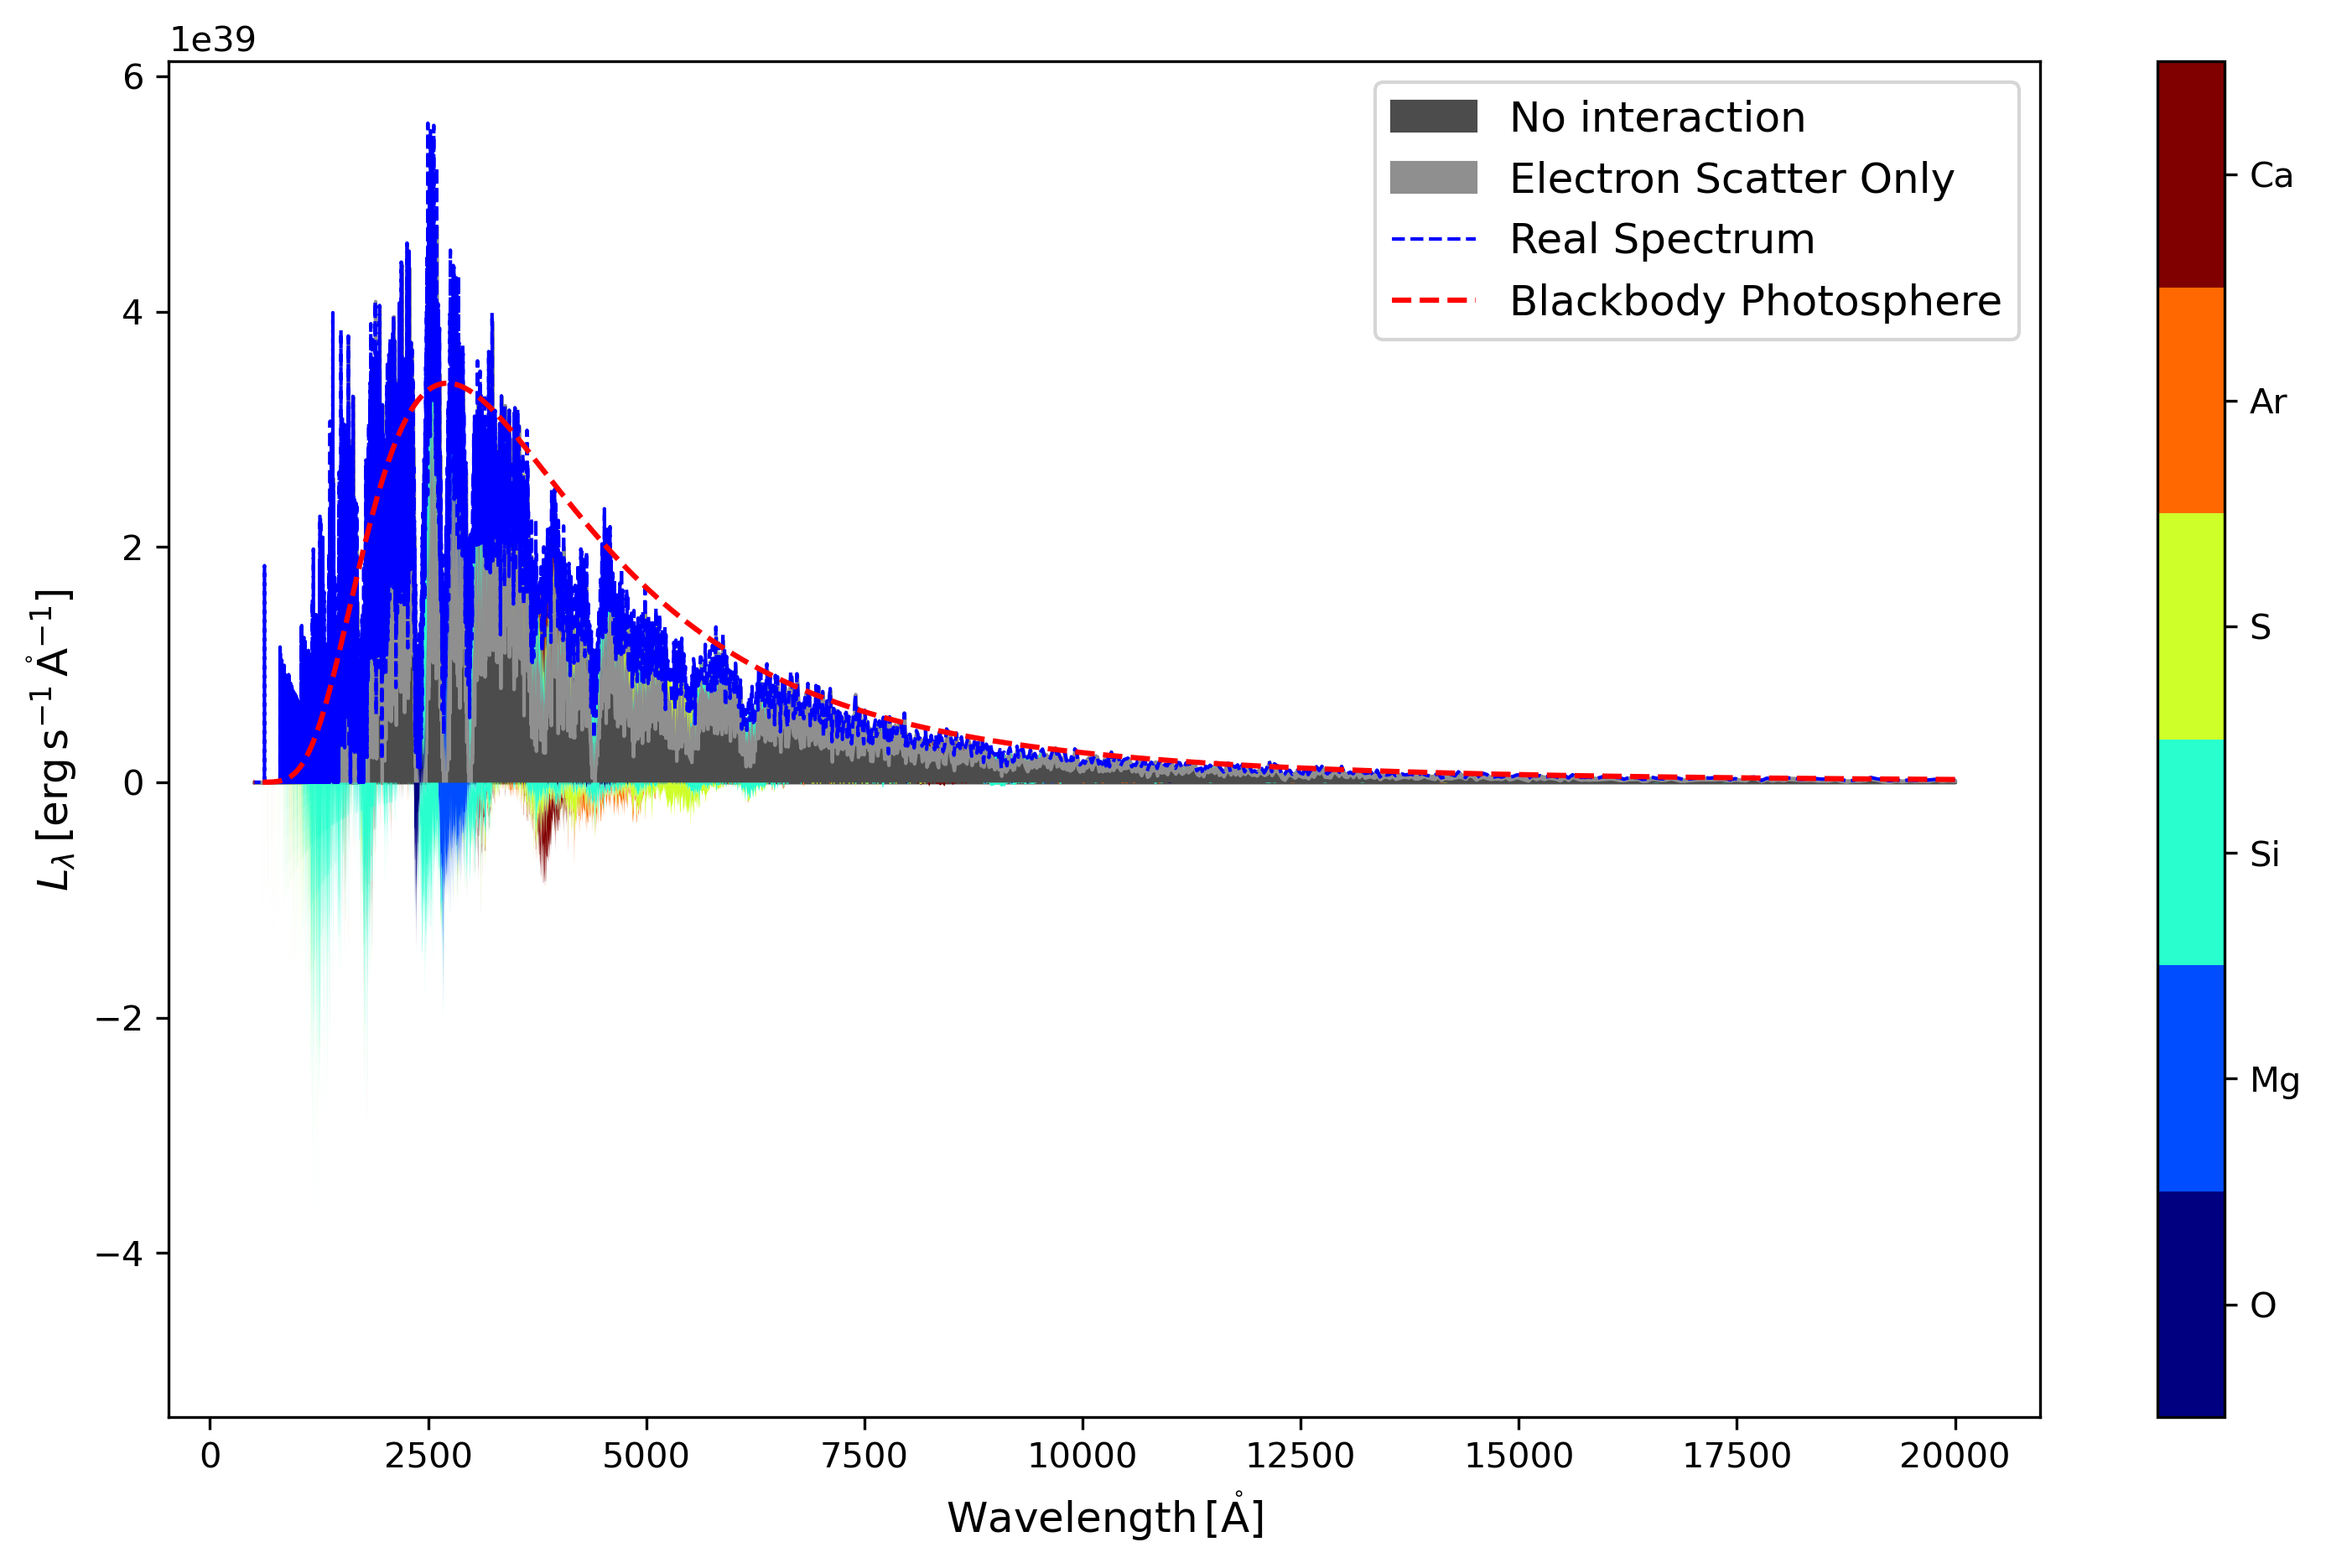

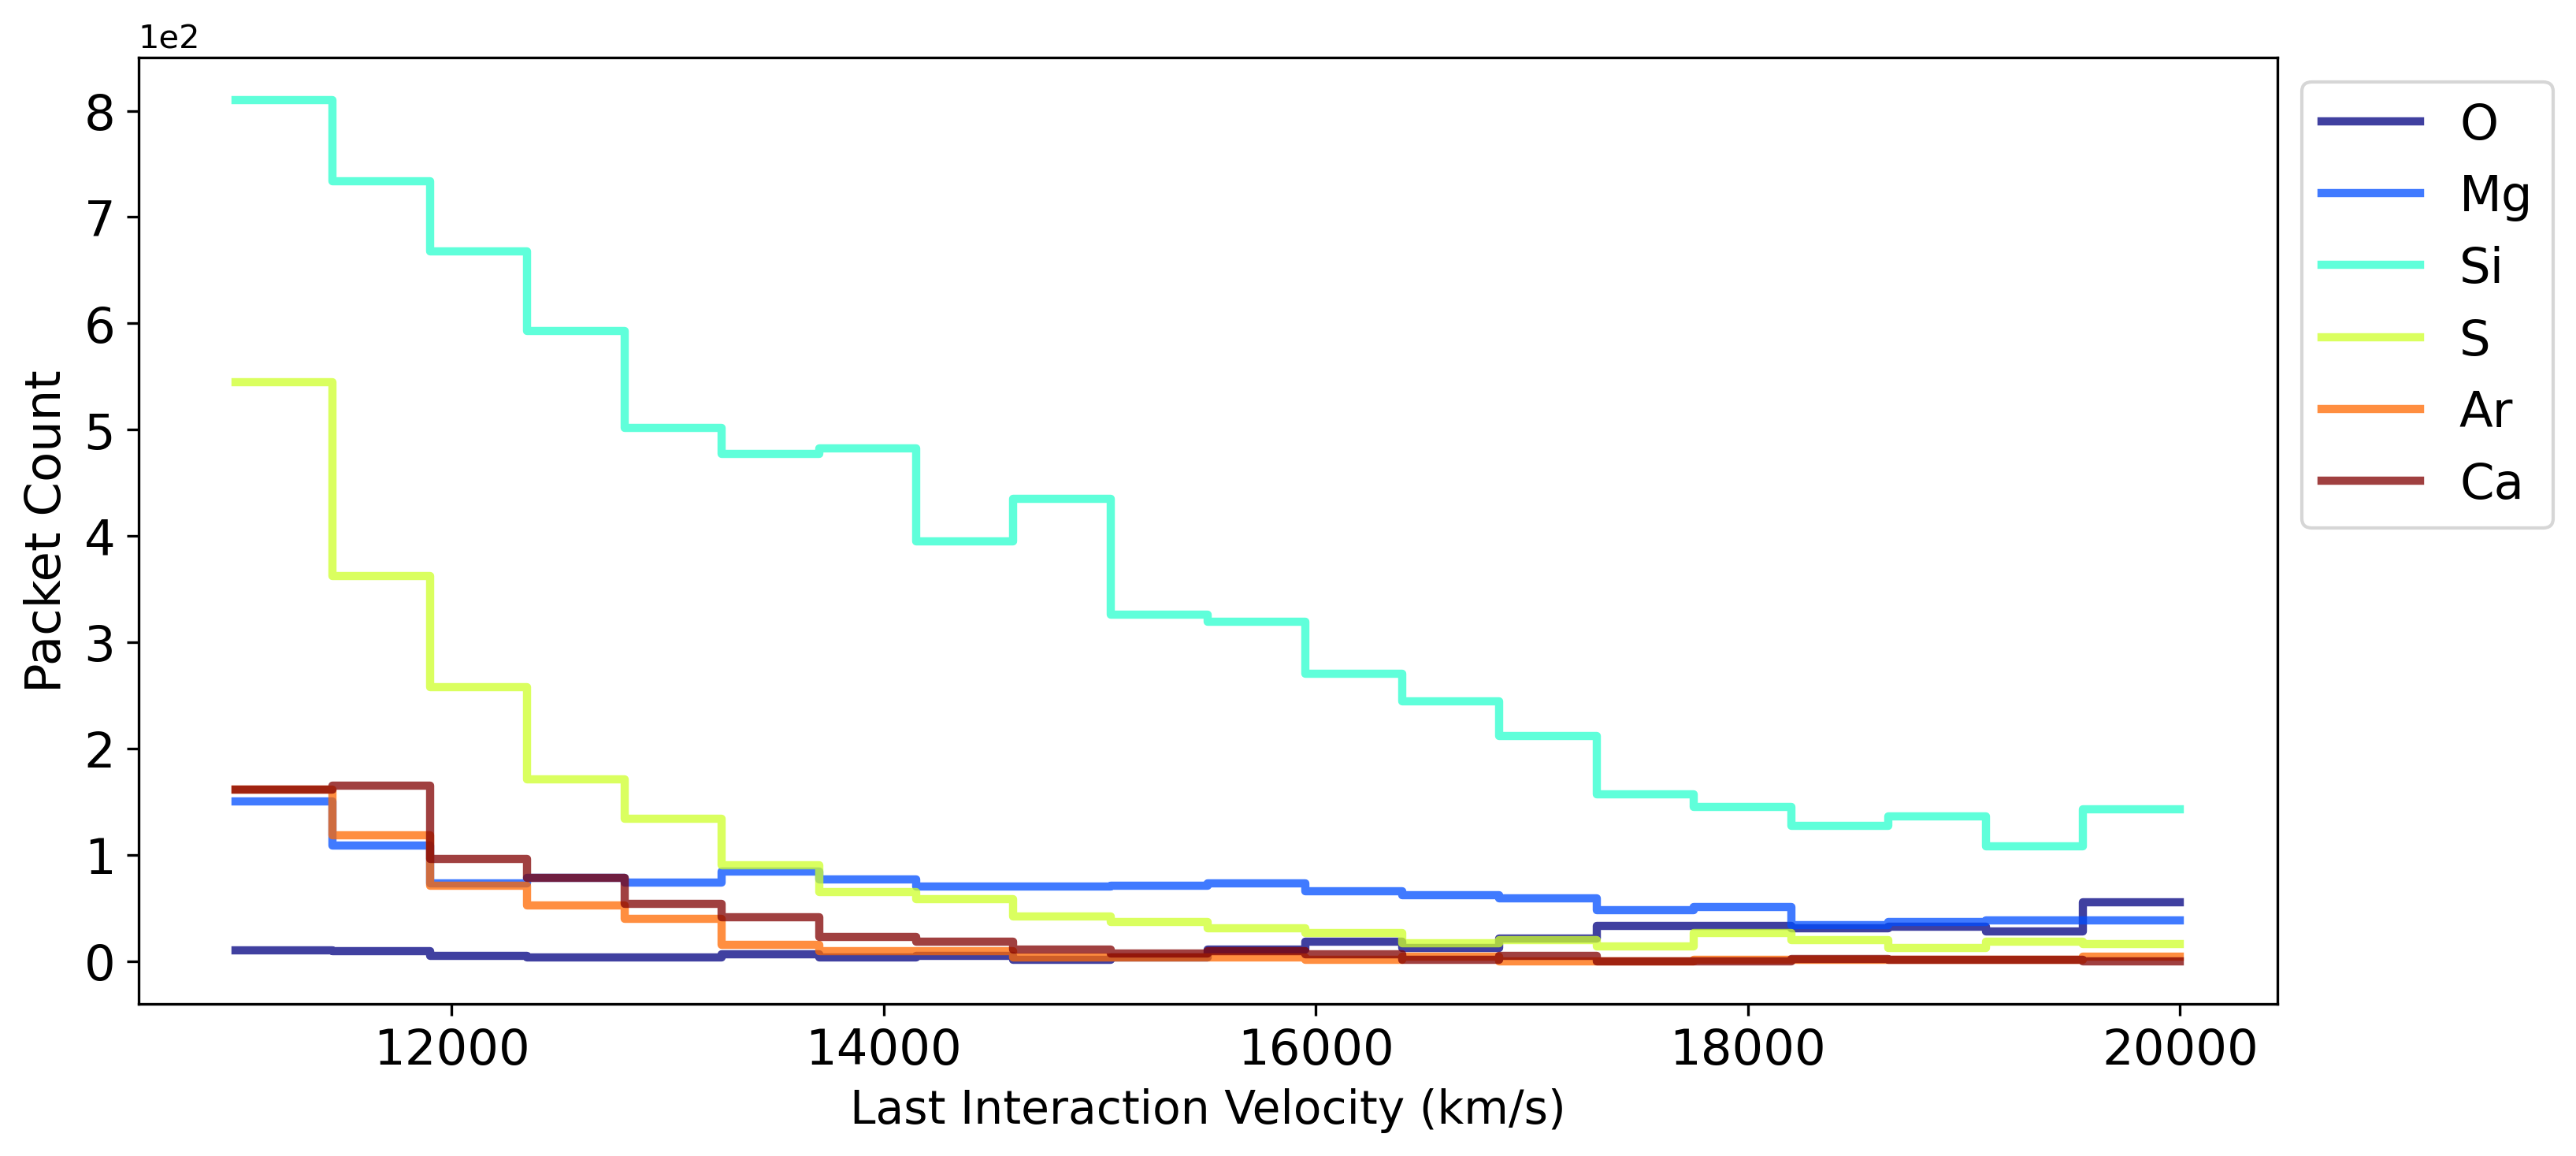

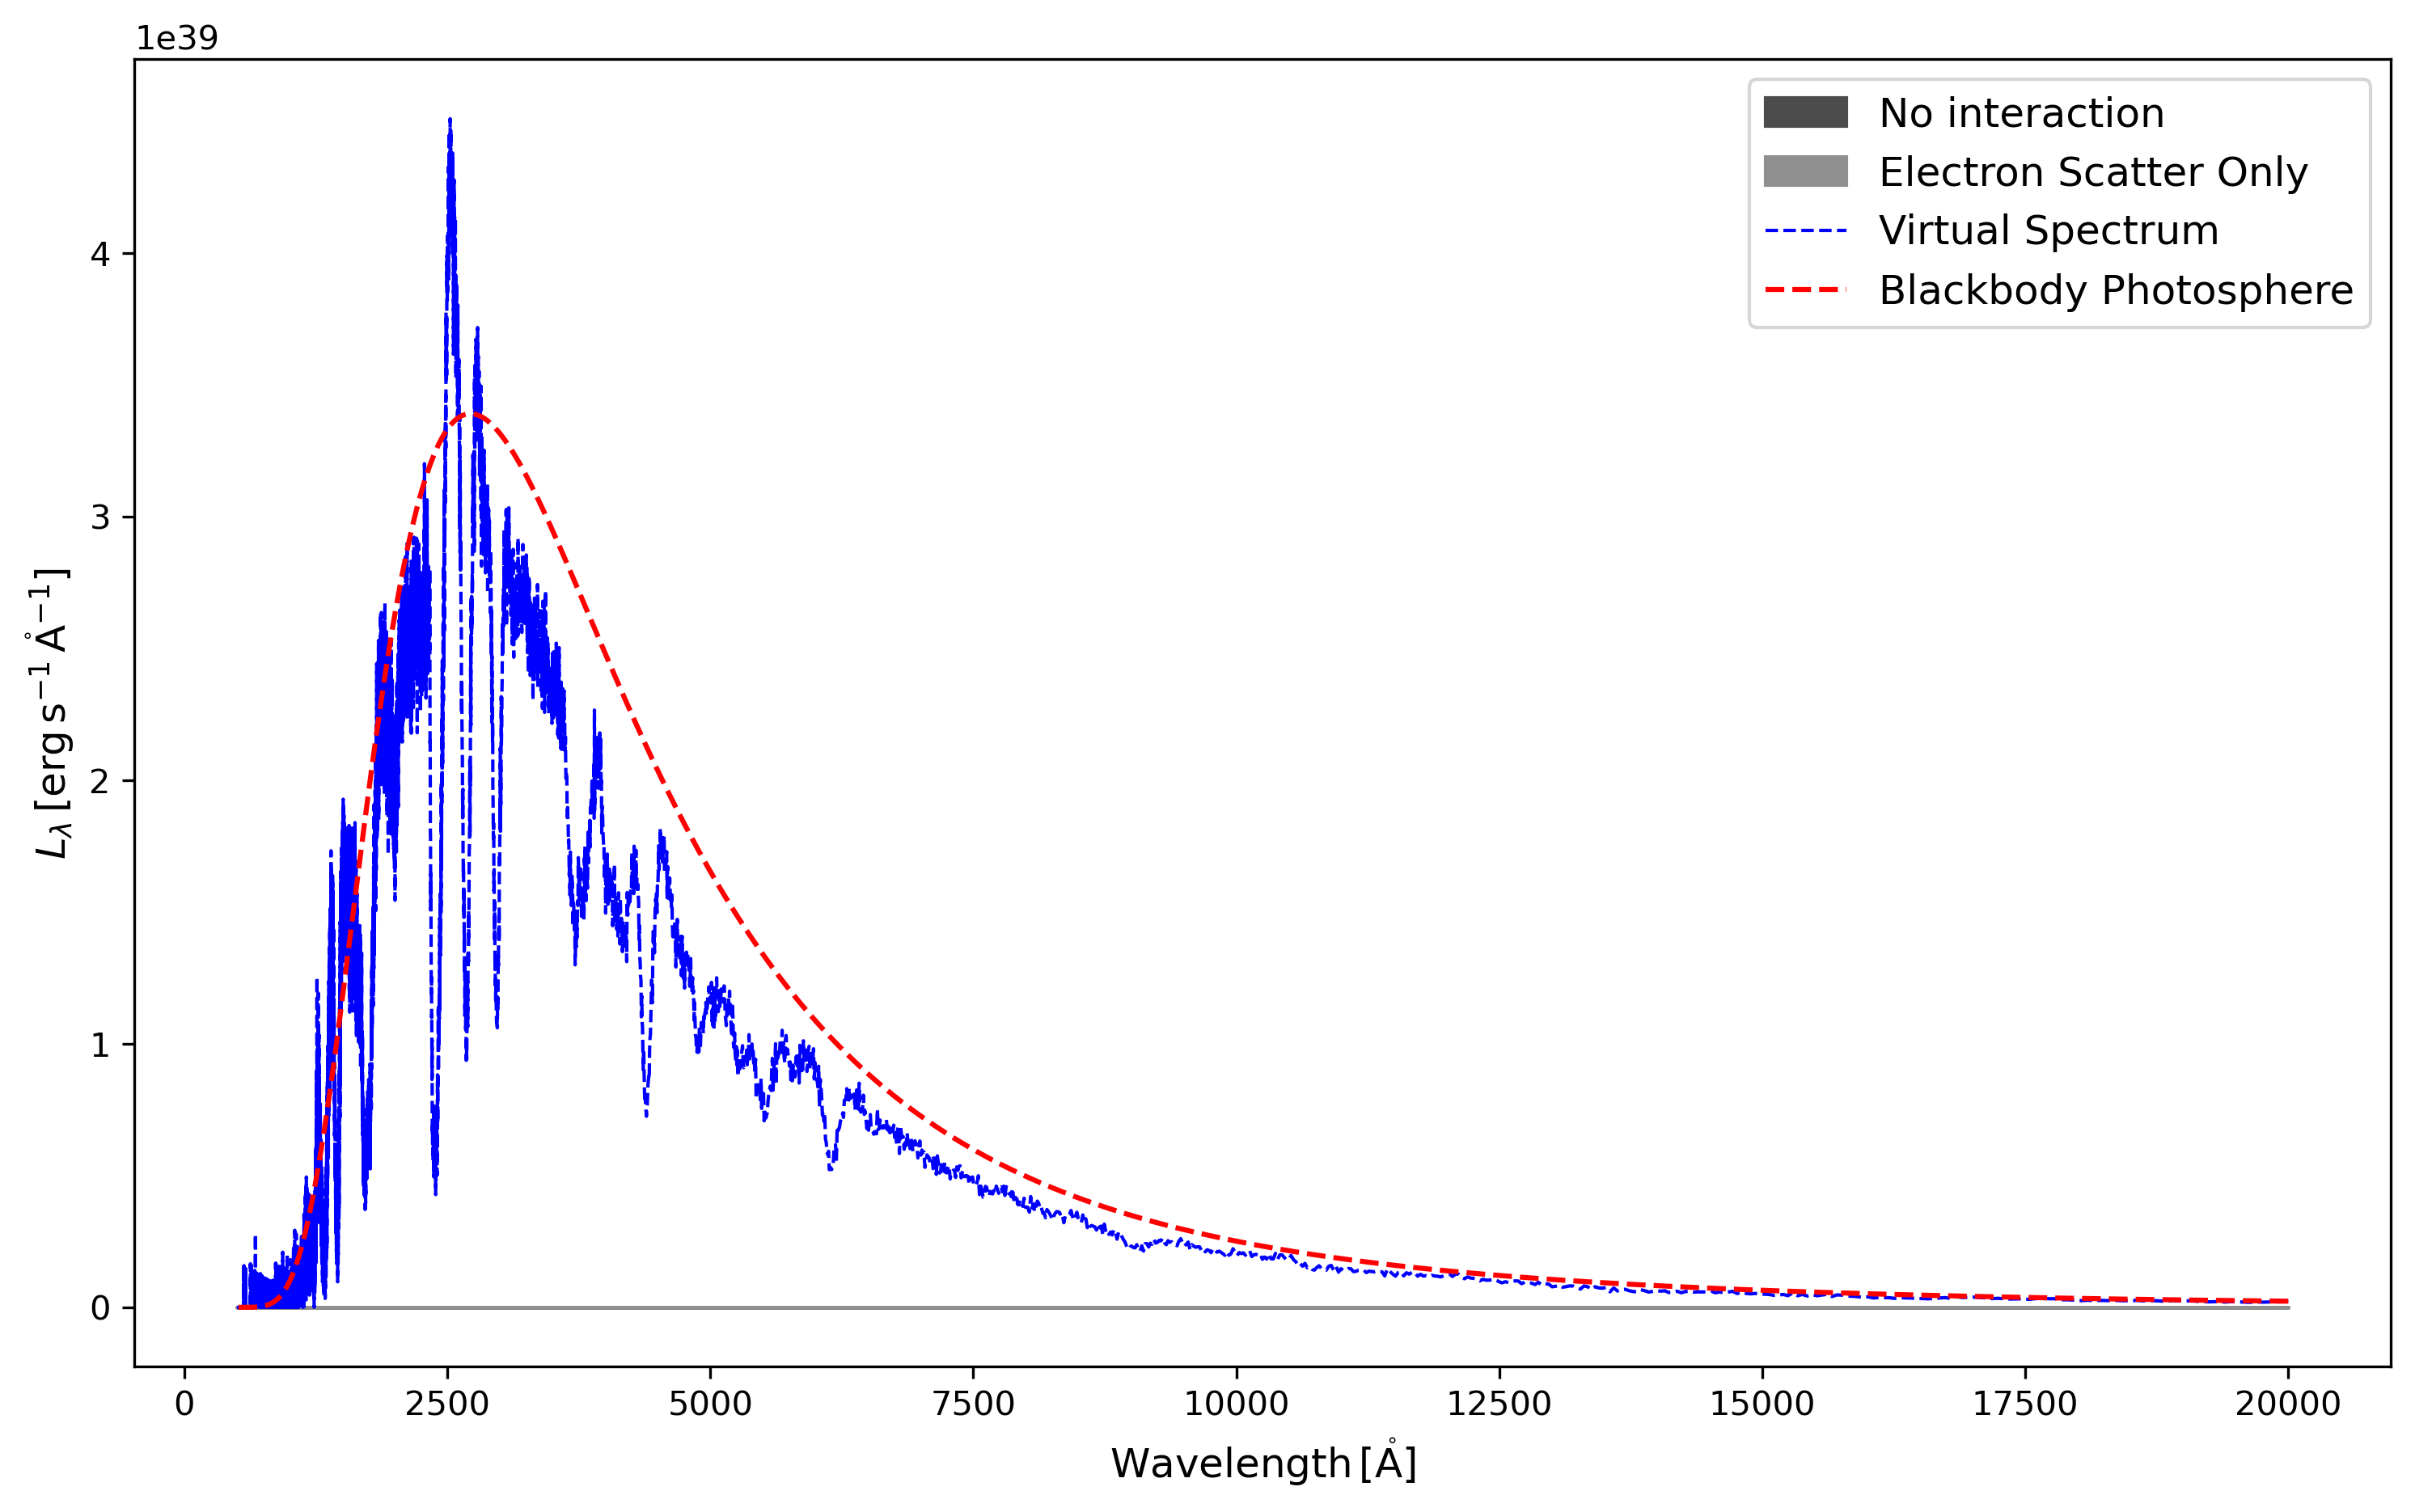

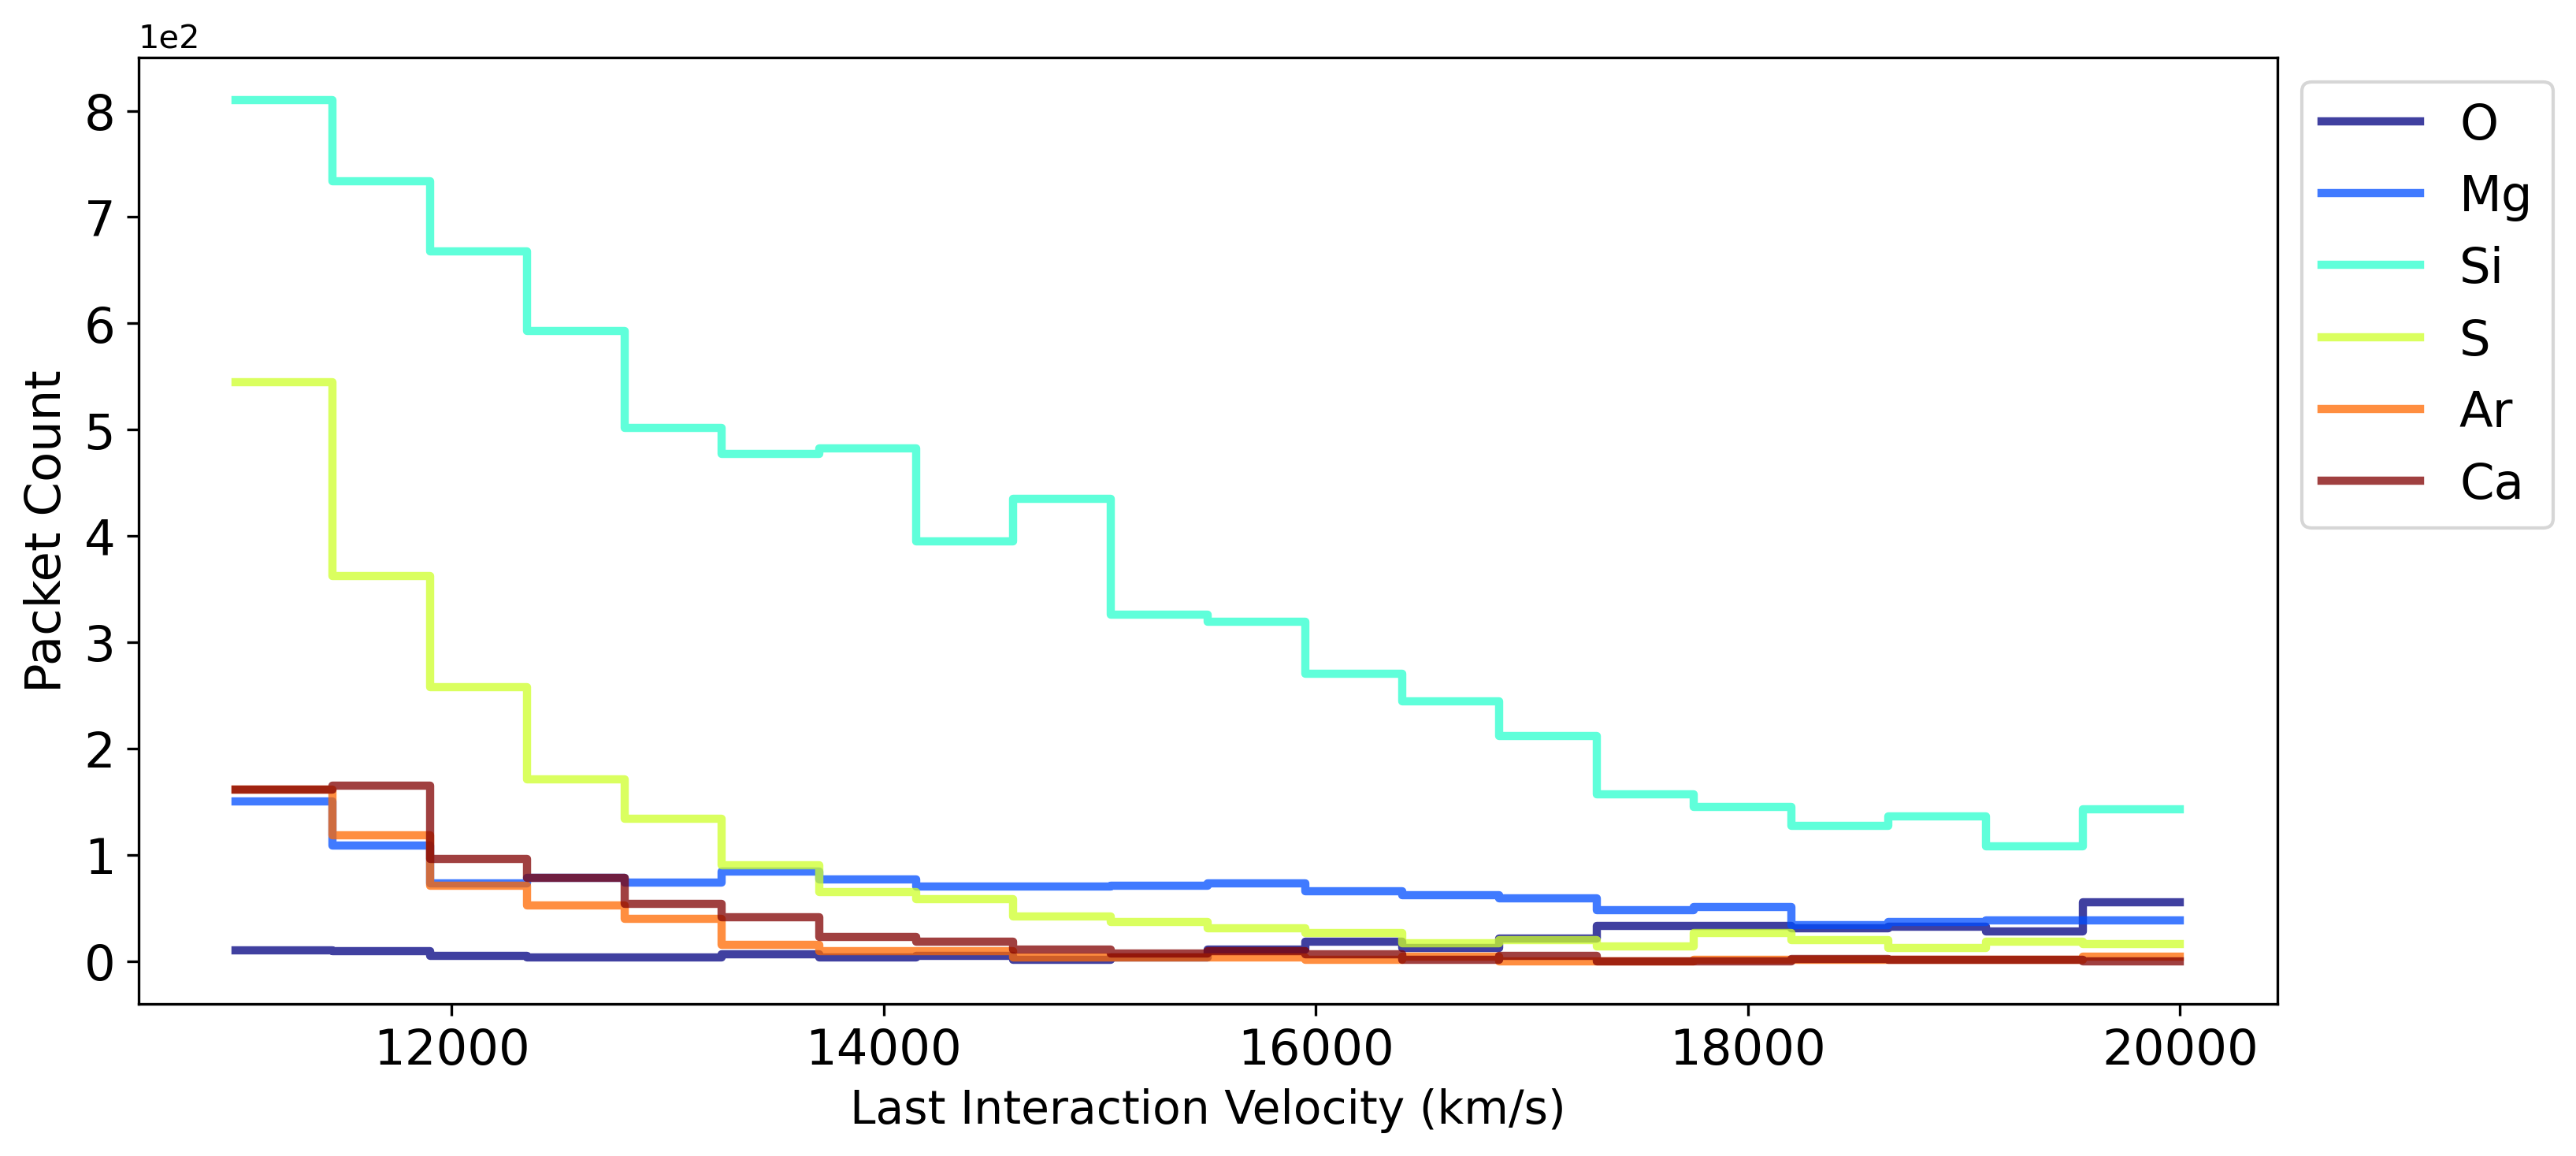

Generated plots in: /home/ad/Desktop/Work/tardis-demo/out


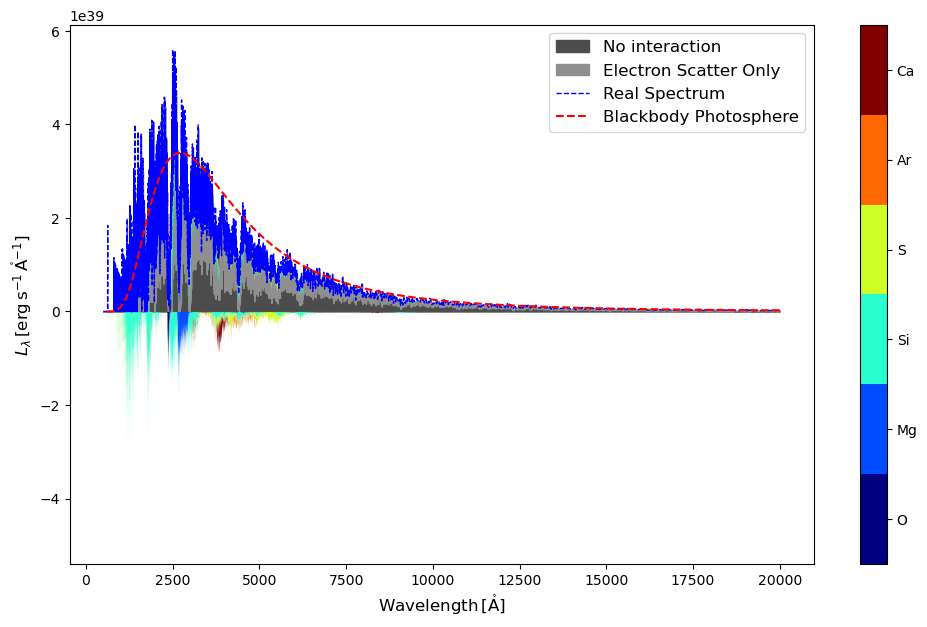

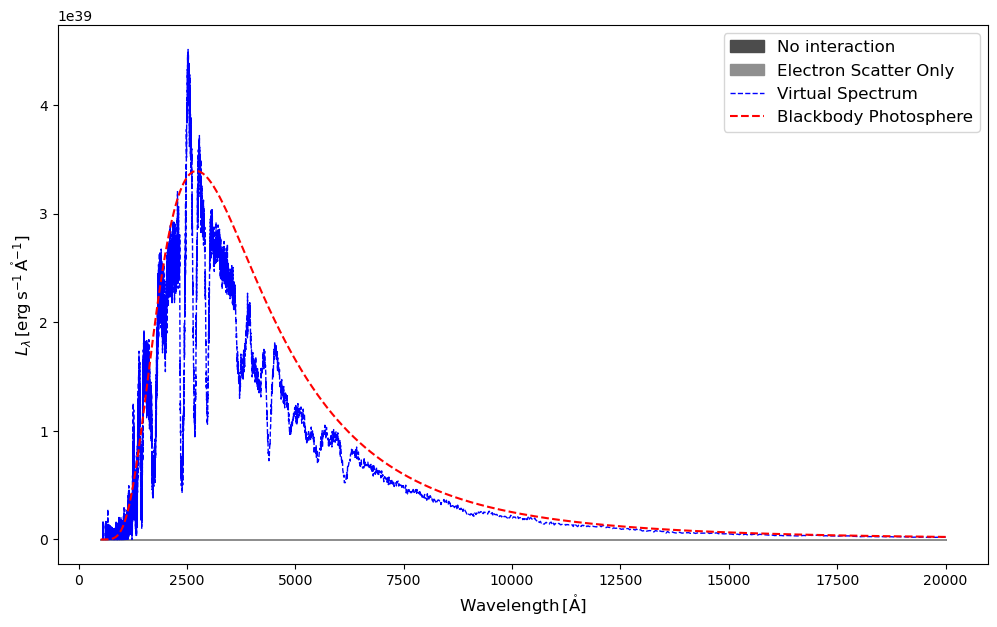

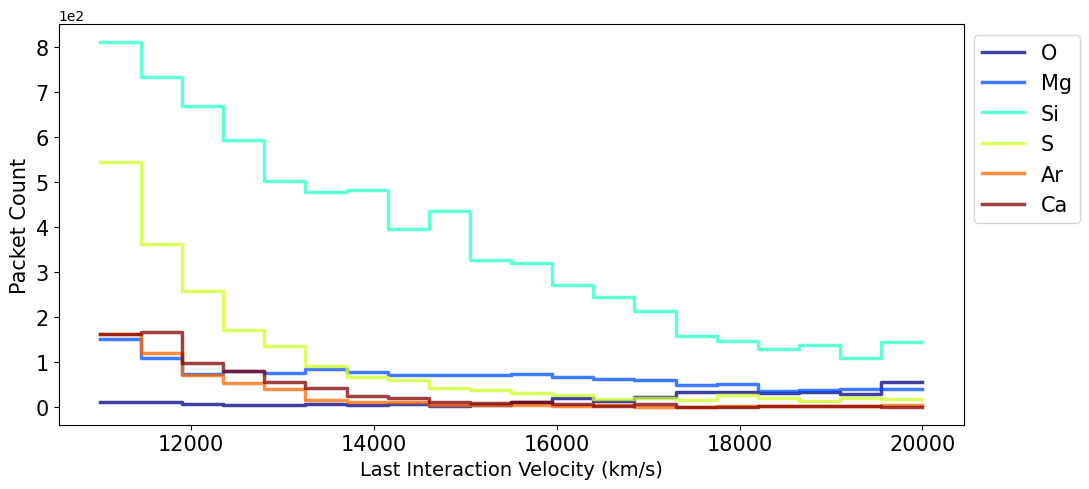

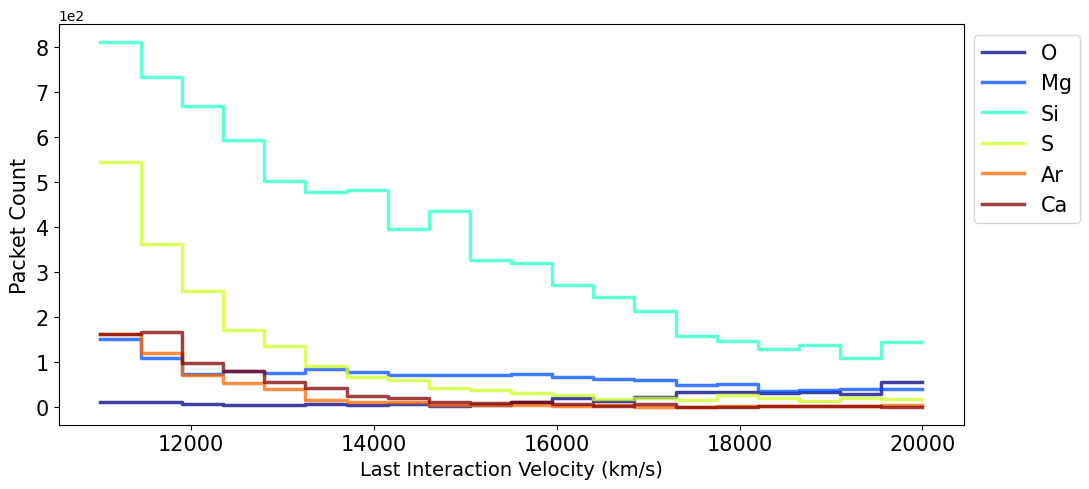

In [19]:
from pathlib import Path
from IPython.display import Image, display

config_path = Path('docs/tardis_example.yml')
output_dir = Path('../tardis-demo/out')
output_prefix = config_path.stem
fmt = 'png'
atom_data = 'kurucz_cd23_chianti_H_He_latest'
download_atom_data(atom_data)
config = Configuration.from_yaml(str(config_path))
sim = run_tardis(
    config,
    atom_data=atom_data,
    virtual_packet_logging=True,
)

save_plots(
    sim,
    [SDECPlotter, LIVPlotter],
    output_prefix=output_prefix,
    output_dir=str(output_dir),
    fmt=fmt,
)

for mode in ('real', 'virtual'):
    display(Image(filename=str(output_dir / f'{output_prefix}_sdecplotter_{mode}.{fmt}')))
    display(Image(filename=str(output_dir / f'{output_prefix}_livplotter_{mode}.{fmt}')))